# 19 · E1f: the adaptation the substrate test found. Is L1 really the closed level?

**What Notebook 18 showed besides its registered result.** Notebook 18 gave L1 a slow K⁺-like current in the *hardware*, with no fitting at all: a share ρ of each neuron's leak acting through a gate with time constant τ_n. At ρ = 0.3 and τ_n = 5 s this realization **failed the equivalence test because it predicted the held-out atlas data better than the fitted L1**: ΔFEVE +0.06 to +0.08 on folds 0, 2 and 3 (−0.04 to +0.00 on the other two).

That clashes with E1. There, the fitted adaptation rung L2 gained only +0.001–0.004 FEVE over L1. The closed level was bracketed as **L0 ≤ closed ≤ L1** (Notebooks 04, 07, 09).

If two global numbers can improve held-out predictions by several hundredths, then either:
* the atlas does contain a slow adaptation-like component that E1's L2 fits did not find (an optimisation or parametrisation failure), or
* the Notebook 18 improvement is fold-specific noise, selected by looking.

**This notebook decides between them.** It uses only what E1 allows:
* For every fold model of the 120-neuron E1 fit, (ρ, τ_n) is chosen on the fold's **training pairs only**, from a 6 × 6 grid; ρ = 0 (plain L1) is always a candidate.
* The chosen model is then scored on the fold's **held-out pairs**.
* The held-out predictions of all folds are assembled into one cross-validated prediction, exactly as in E1, and bootstrapped over stimulated neurons.

Two controls:
* **Gain control.** Adaptation lowers sustained responses, so it could merely act as a smaller global gain. L1 × c, with c fitted on the training pairs, tests that.
* **Null control.** Synthetic data generated by L1 itself (each fold's model, plus noise with the atlas's measured trial variance) are run through the same selection. Adaptation must *not* "help" there.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 16, 0), \
    f"Notebook 19 needs closurebench >= 0.16.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_, substrates as SB, conductance as CD, intrinsic as IN
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke":  dict(N_COLS=10, FOLDS_USED=1),
        "laptop": dict(N_COLS=None, FOLDS_USED=None),
        "full":   dict(N_COLS=None, FOLDS_USED=None)}[MODE]
globals().update(CONF)
RHOS, TAU_NS = (0.0, 0.1, 0.2, 0.3, 0.45, 0.6), (0.5, 1.0, 2.0, 5.0, 10.0, 20.0)
N_BOOT, E1_THRESHOLD = 2000, 0.05
TAG = "" if MODE == "full" else f"_{MODE}"

# ---- the fitted L1 models of Notebook 04 (as in Notebook 05); smoke falls back to a synthetic L1 if they are absent
E1_TAG = "_laptop" if MODE == "smoke" else TAG
try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    e1_plan = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))
    assert e1_result["L_star"] == "L1", "conductance.py implements L1"
    c = e1_plan["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"])
    ck1 = os.path.join(RESULTS, f"e1_checkpoints{E1_TAG}")
    models = [pickle.load(open(os.path.join(ck1, f"fold{f}_L1_final.pkl"), "rb"))["params"] for f in range(c["k_folds"])]
    SOURCE = f"E1 fits ({E1_TAG.strip('_') or 'full'})"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 fits not found (", err, ") -> smoke test on a synthetic L1")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=30, S=10, seed=1, strains=("wt",)), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = [None]; models = [p_true]; SOURCE = "synthetic L1"
rng = np.random.default_rng(0)
COLS = np.sort(rng.choice(ds.S, N_COLS, replace=False)) if N_COLS and N_COLS < ds.S else np.arange(ds.S)
FOLDS = list(range(len(models)))[:FOLDS_USED] if FOLDS_USED else list(range(len(models)))
print(f"source: {SOURCE} | {ds.N} neurons | {len(COLS)} stimuli | fold models {FOLDS}")
if folds[0] is None:                       # smoke fallback: a synthetic L1 has no folds -> make two (negative control: no adaptation in the truth)
    folds = M_.kfold_pairs(ds, 2, 0); models = [models[0]] * 2; FOLDS = [0, 1]
print(f"grid: rho {RHOS} x tau_n {TAU_NS} s ({(len(RHOS) - 1) * len(TAU_NS) + 1} candidates per fold, rho = 0 is L1 itself)")

source: E1 fits (laptop) | 120 neurons | 120 stimuli | fold models [0, 1, 2, 3, 4]
grid: rho (0.0, 0.1, 0.2, 0.3, 0.45, 0.6) x tau_n (0.5, 1.0, 2.0, 5.0, 10.0, 20.0) s (31 candidates per fold, rho = 0 is L1 itself)


### Pre-registration (before §1)

Recorded in `results/E1f_preregistration*.json`. Predictions use the continuous-time simulation (RK4, dt = 0.02 s; within 0.0012 × noise of E1's Euler fit, Notebook 05). FEVE is computed on wild-type pairs, and bootstraps resample stimulated neurons (2000 draws).

* **ADAPTATION_HELPS:** the cross-validated held-out FEVE gain of L1 + slow current over L1 has a 95 % bootstrap CI whose lower bound is > 0.
* **BEYOND_GAIN:** the same holds against the gain control (L1 × c).
* **CLOSED_LEVEL_DEEPER:** ADAPTATION_HELPS **and** BEYOND_GAIN **and** a point gain ≥ 0.05, E1's sufficiency margin (5 % of the noise ceiling). The closed level would then be *deeper* than L1, and E1's bracket would be wrong.
* **VALID:** on the null-control data, the same procedure's gain has a CI lower bound ≤ 0, i.e. no false positive. The rules above are read only if VALID.

In [3]:
prereg = os.path.join(RESULTS, f"E1f_preregistration{TAG}.json")
plan = {"experiment": "E1f slow adaptation vs L1", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "source": SOURCE, "config": {"folds": FOLDS, "rho": list(RHOS), "tau_n_s": list(TAU_NS), "n_boot": N_BOOT, "strain": "wt"},
        "selection": "per fold: (rho, tau_n) maximising training-pair FEVE; rho = 0 (L1) included",
        "ADAPTATION_HELPS": "95% bootstrap CI (stimulated neurons) of held-out FEVE gain over L1 has lower bound > 0",
        "BEYOND_GAIN": "same against L1 x c (c fitted on training pairs)",
        "CLOSED_LEVEL_DEEPER": f"ADAPTATION_HELPS and BEYOND_GAIN and point gain >= {E1_THRESHOLD}",
        "VALID": "on L1-generated null data the procedure's gain CI lower bound <= 0"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1f_preregistration_laptop.json


## 1 · Simulate every candidate for every fold model (checkpointed)

~30 simulations per fold, a few seconds each.

In [4]:
CK = os.path.join(RESULTS, "e1f_ck", MODE); os.makedirs(CK, exist_ok=True)
SIM = {}
for f in FOLDS:
    ck = os.path.join(CK, f"fold{f}.npz")
    if os.path.exists(ck):
        z = np.load(ck); SIM[f] = {tuple(map(float, k.split("_"))): z[k] for k in z.files}; print(f"fold {f}: loaded"); continue
    t0 = time.time()
    p = jax.tree_util.tree_map(jax.numpy.asarray, models[f])
    e = SB.effective_params("L1", p, st, COLS)
    Vr, _ = CD.rest_state(e, cfg)
    sims = {(0.0, 0.0): SB.simulate_numpy(e, ds.stim[COLS], cfg, "rk4", dt=0.02)}
    for rho in RHOS[1:]:
        for tn in TAU_NS:
            sims[(rho, tn)] = IN.simulate_slow_k(e, ds.stim[COLS], cfg, Vr, rho=rho, tau_n=tn)
    SIM[f] = sims
    np.savez(ck, **{f"{k[0]}_{k[1]}": v for k, v in sims.items()})
    print(f"fold {f}: {len(sims)} simulations ({time.time() - t0:.0f} s)", flush=True)

fold 0: 31 simulations (86 s)
fold 1: 31 simulations (88 s)
fold 2: 31 simulations (84 s)
fold 3: 31 simulations (113 s)
fold 4: 31 simulations (110 s)


## 2 · Select on training pairs, score on held-out pairs

In [5]:
import copy
def full(R):
    """(N, len(COLS)) WT prediction -> (n_strain, N, S) array (other strains copied; scored on WT only)."""
    out = np.zeros(ds.mean.shape[:3]); out[:, :, COLS] = R[None]; return out

def run_selection(data):
    """Per fold: pick (rho, tau_n) on training pairs; fit the gain-control c on training pairs.
    Returns cross-validated (n_strain, N, S) predictions for L1, L1 x c, L1 + slow current, and the choices."""
    cv = {k: np.zeros(data.mean.shape[:3]) for k in ("L1", "L1_gain", "L1_slowK")}
    choice = {}
    for f in FOLDS:
        test = folds[f]; train = np.zeros_like(test)
        for g in range(len(folds)):
            if g != f: train |= folds[g]
        tr_feve = {k: M_.feve(full(R), data, strain="wt", extra_mask=train) for k, R in SIM[f].items()}
        best = max(tr_feve, key=tr_feve.get); choice[f] = (best, tr_feve[best] - tr_feve[(0.0, 0.0)])
        R1 = full(SIM[f][(0.0, 0.0)]); m = data.mask() & train; m[1:] = False
        c = float((R1[m] * data.mean[m]).sum() / max((R1[m] ** 2).sum(), 1e-12))
        for k, R in (("L1", R1), ("L1_gain", c * R1), ("L1_slowK", full(SIM[f][best]))):
            cv[k][test] = R[test]
        choice[f] = choice[f] + (c,)
    return cv, choice

def gain_test(cv, data, a, b):
    point, boots = M_.bootstrap_feve({a: cv[a], b: cv[b]}, data, [a, b], n_boot=N_BOOT, seed=1, strain="wt")
    d = boots[a] - boots[b]
    return point[a] - point[b], np.percentile(d, [2.5, 97.5]), point

cv, choice = run_selection(ds)
for f, (best, tr_gain, c) in choice.items():
    print(f"fold {f}: chosen rho {best[0]:.2f}, tau_n {best[1]:g} s (training FEVE gain {tr_gain:+.4f}); gain control c = {c:.3f}")
g1, ci1, pt = gain_test(cv, ds, "L1_slowK", "L1")
g2, ci2, _ = gain_test(cv, ds, "L1_slowK", "L1_gain")
gg, cig, _ = gain_test(cv, ds, "L1_gain", "L1")
print(f"\ncross-validated held-out FEVE (WT): L1 {pt['L1']:.4f} | L1 + slow current {pt['L1_slowK']:.4f}")
print(f"gain over L1:            {g1:+.4f}  95% CI [{ci1[0]:+.4f}, {ci1[1]:+.4f}]")
print(f"gain over gain control:  {g2:+.4f}  95% CI [{ci2[0]:+.4f}, {ci2[1]:+.4f}]")
print(f"(gain control alone over L1: {gg:+.4f}  95% CI [{cig[0]:+.4f}, {cig[1]:+.4f}])")

fold 0: chosen rho 0.10, tau_n 20 s (training FEVE gain +0.0369); gain control c = 1.315
fold 1: chosen rho 0.10, tau_n 20 s (training FEVE gain +0.0369); gain control c = 1.237
fold 2: chosen rho 0.10, tau_n 20 s (training FEVE gain +0.0259); gain control c = 1.210
fold 3: chosen rho 0.20, tau_n 5 s (training FEVE gain +0.0320); gain control c = 1.214
fold 4: chosen rho 0.10, tau_n 20 s (training FEVE gain +0.0475); gain control c = 1.298

cross-validated held-out FEVE (WT): L1 0.2630 | L1 + slow current 0.2885
gain over L1:            +0.0254  95% CI [+0.0129, +0.0390]
gain over gain control:  +0.0425  95% CI [+0.0255, +0.0668]
(gain control alone over L1: -0.0171  95% CI [-0.0371, -0.0019])


## 3 · Null control: does the procedure invent adaptation in L1-generated data?

null-control choices: {0: (0.2, 0.5), 1: (0.2, 0.5), 2: (0.3, 0.5), 3: (0.2, 0.5), 4: (0.3, 0.5)}
null-control gain over L1: -0.0095  95% CI [-0.0247, -0.0005]

Registered rules -> VALID: True | ADAPTATION_HELPS: True | BEYOND_GAIN: True | CLOSED_LEVEL_DEEPER: False


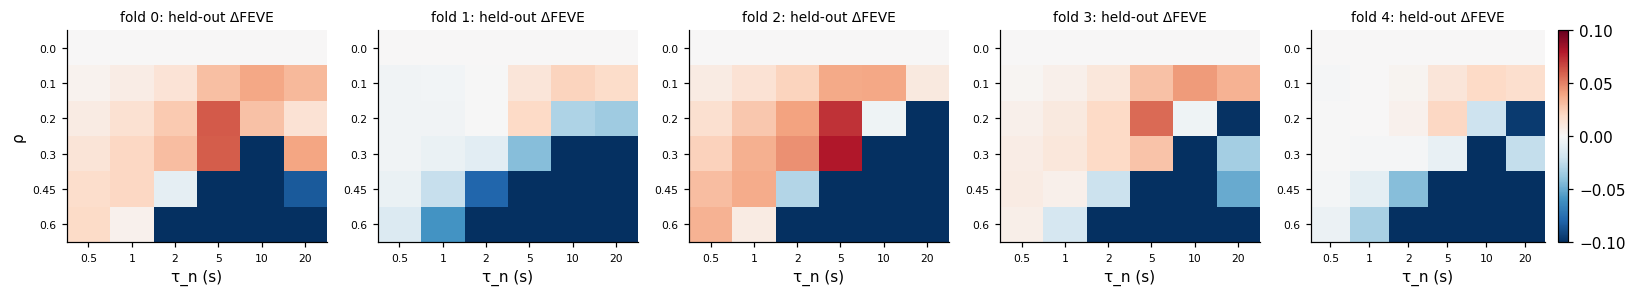

In [6]:
rng = np.random.default_rng(7)
ds_null = copy.deepcopy(ds)
for f in FOLDS:                                              # each fold's own held-out pairs come from that fold's L1
    R = full(SIM[f][(0.0, 0.0)]); m = folds[f] & ds.mask()
    ds_null.mean[m] = R[m]
m = ds.mask()
ds_null.mean[m] = ds_null.mean[m] + rng.normal(size=m.sum()) * np.sqrt(ds.var_mean[m])
cv0, choice0 = run_selection(ds_null)
g0, ci0, _ = gain_test(cv0, ds_null, "L1_slowK", "L1")
print("null-control choices:", {f: (b[0], b[1]) for f, (b, _, _) in choice0.items()})
print(f"null-control gain over L1: {g0:+.4f}  95% CI [{ci0[0]:+.4f}, {ci0[1]:+.4f}]")
VALID = bool(ci0[0] <= 0)
ADAPTATION_HELPS = bool(ci1[0] > 0); BEYOND_GAIN = bool(ci2[0] > 0)
CLOSED_LEVEL_DEEPER = bool(ADAPTATION_HELPS and BEYOND_GAIN and g1 >= E1_THRESHOLD)
print(f"\nRegistered rules -> VALID: {VALID} | ADAPTATION_HELPS: {ADAPTATION_HELPS} | BEYOND_GAIN: {BEYOND_GAIN} | CLOSED_LEVEL_DEEPER: {CLOSED_LEVEL_DEEPER}"
      + ("" if VALID else "  (not interpretable: the procedure finds adaptation in L1-generated data)"))
fig, ax = plt.subplots(1, len(FOLDS), figsize=(3 * len(FOLDS), 2.8), squeeze=False)
for a, f in zip(ax[0], FOLDS):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    G = np.array([[M_.feve(full(SIM[f][(rho, tn)] if rho else SIM[f][(0.0, 0.0)]), ds, strain="wt", extra_mask=test) for tn in TAU_NS] for rho in RHOS])
    im = a.imshow(G - G[0, 0], cmap="RdBu_r", vmin=-0.1, vmax=0.1, aspect="auto")
    a.set_xticks(range(len(TAU_NS))); a.set_xticklabels([f"{t:g}" for t in TAU_NS], fontsize=7); a.set_yticks(range(len(RHOS))); a.set_yticklabels(RHOS, fontsize=7)
    a.set_xlabel("τ_n (s)"); a.set_title(f"fold {f}: held-out ΔFEVE", fontsize=9)
ax[0][0].set_ylabel("ρ"); plt.colorbar(im, ax=ax[0][-1], fraction=0.05); plt.tight_layout(); plt.show()

In [7]:
out = {"source": SOURCE, "choices": {str(f): {"rho": b[0], "tau_n": b[1], "train_gain": tg, "gain_c": c} for f, (b, tg, c) in choice.items()},
       "heldout": {"L1": pt["L1"], "L1_slowK": pt["L1_slowK"]},
       "gain_vs_L1": {"point": g1, "ci": list(ci1)}, "gain_vs_gaincontrol": {"point": g2, "ci": list(ci2)},
       "null": {"point": g0, "ci": list(ci0)},
       "VALID": VALID, "ADAPTATION_HELPS": ADAPTATION_HELPS, "BEYOND_GAIN": BEYOND_GAIN, "CLOSED_LEVEL_DEEPER": CLOSED_LEVEL_DEEPER}
json.dump(out, open(os.path.join(RESULTS, f"E1f_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E1f_result{TAG}.json")

saved E1f_result_laptop.json


## Results (laptop mode, executed on the M1: all 5 fold models, all 120 stimuli)

**Selections on training pairs.** Four of five folds chose **ρ = 0.1, τ_n = 20 s**, the slowest time constant in the grid; fold 3 chose ρ = 0.2, τ_n = 5 s. Training-pair gains were +0.026 to +0.048.

**Held-out (cross-validated, WT, bootstrap over stimulated neurons):**

| comparison | gain | 95 % CI |
|---|---|---|
| L1 + slow current vs fitted L1 (0.263 → 0.289) | **+0.025** | [+0.013, +0.039] |
| L1 + slow current vs gain control (L1 × c) | **+0.043** | [+0.026, +0.067] |
| gain control vs L1 | −0.017 | [−0.037, −0.002] |
| *null control* (L1-generated data): slow current vs L1 | −0.010 | [−0.025, −0.001] |

**Registered rules:**
* VALID: yes. On L1-generated data the selection picks a fast, weak current (τ_n = 0.5 s), which *hurts* held-out predictions slightly. The procedure does not invent the effect.
* ADAPTATION_HELPS: yes.
* BEYOND_GAIN: yes. A uniform output gain fitted on training pairs (c = 1.21–1.32) even makes held-out predictions worse.
* CLOSED_LEVEL_DEEPER: no. +0.025 is half of E1's 0.05 margin.

**Outcome: the second row of the table below.** The improvement is real, cross-validated and not a gain change, but below E1's sufficiency margin.

**A caution on what "adaptation" means here.** The preferred τ_n sits at the *edge* of the grid (20 s, as long as the response window). A gate that slow barely moves during a response. In the limit τ_n → ∞, the slow current is only a weaker leak for transients around an unchanged resting state, and that is **exactly an L1 with rescaled parameters** (slower, more strongly coupled, more strongly driven). So the gain may mean either:
* the atlas holds slow adaptation, or
* E1's L1 fits were not at the best point of their own family, consistent with their underfitting in Notebook 04.

**Notebook 20 (E1g) separates the two.**

> **Caveat (added 2026-10-08, after Notebook 20).** Notebook 20's sanity check showed that the models compared here did not start from the same state:
> * L1 was simulated from zero with a 30-s burn-in, which probably does not reach rest for these fits (slowest relaxation 6–12 s, Notebook 05);
> * the slow currents started from L1's state after that burn-in, with their gate frozen there.
>
> Part of the +0.025 gain may therefore come from the inconsistent start rather than from adaptation. **Notebook 21 re-tests it with every model started from the exact resting state.**
>
> **Resolved (Notebook 21).** With every model started from its exact resting state, the gain survives: **+0.025 [+0.011, +0.041]** over L1\*. About half of it a rescaled L1 also gets; the other half needs the slow dynamics (+0.0125 [+0.004, +0.024]). It is still below the 0.05 margin. Notebook 22 tests it with *fitted* models.

## 4 · Reading the result

| outcome | reading |
|---|---|
| CLOSED_LEVEL_DEEPER | A slow, global adaptation (two numbers) improves held-out interventional predictions beyond L1 and beyond a gain change, by more than E1's margin. **E1's bracket L0 ≤ closed ≤ L1 is wrong**: the closed level includes slow adaptation, and the ladder's L2 fits failed to find it. That is an optimisation or parametrisation failure of the L2 rung, worth fixing before E1 is re-run. |
| **ADAPTATION_HELPS and BEYOND_GAIN, gain < 0.05 ← observed (+0.025)** | Real, but below E1's sufficiency margin. Slow adaptation is *detectable* in the atlas yet not large enough to move the closed level under E1's rule. It marks the place where the 5-s-pulse experiment (Notebook 08) would add the most. |
| ADAPTATION_HELPS only | The improvement is a gain recalibration, not dynamics. |
| neither | Notebook 18's fold-wise improvements were selection noise. E1's bracket stands. |
| VALID fails | The selection invents adaptation in L1-generated data; nothing can be read. |

**Limits.**
* One global slow current (two numbers) is a deliberately minimal adaptation. Per-neuron or per-class adaptation could gain more, at the cost of identifiability (Notebook 07).
* The null control uses each fold's own L1 as the truth, with the atlas's trial variance. It checks the selection procedure, not every possible artefact.